Part B

In [26]:
import torch
import torch.nn as nn
import torch.optim as optim
import scipy.io as sio
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import TensorDataset, DataLoader
from tqdm import tqdm

class RIS_DNN(nn.Module):
    def __init__(self):
        super(RIS_DNN, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(256, 500), nn.ReLU(),
            nn.Linear(500, 250), nn.ReLU(),
            nn.Linear(250, 120), nn.ReLU(),
            nn.Linear(120, 16), nn.Sigmoid()
        )
    def forward(self, x):
        return self.network(x)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Device:", device)

Device: cpu


In [5]:
#Dataset Generation

In [172]:
import numpy as np
import scipy.io as sio

np.random.seed(42)

# PARAMETERS
N_sc = 64
N_cp = 16
num_frames = 3000   # use 3000 for debug, 40000 for final
SNR_dB = np.arange(0, 31, 5)

num_BS = 4
RIS_els = 16 * 16
num_paths = 10   # 🔥 reduced → more stable learning

# ----------------------------
# QPSK
# ----------------------------
def qpsk_mod(bits):
    return (2*(bits % 2) - 1 + 1j*(2*(bits // 2) - 1)) / np.sqrt(2)

# ----------------------------
# FIXED BASE CHANNEL (IMPORTANT)
# ----------------------------
def generate_base_channel():
    # One base channel reused across frames (key fix)
    h = np.zeros(N_sc, dtype=complex)
    for p in range(num_paths):
        delay = np.random.randint(0, N_cp)
        gain = (np.random.randn() + 1j*np.random.randn()) / np.sqrt(2*num_paths)
        h[delay] += gain
    return np.fft.fft(h)

H_base = generate_base_channel()

# STORAGE
DL_RIS_Y_pilot = np.zeros((num_frames, len(SNR_dB), N_sc), dtype=complex)
DL_RIS_Y_data  = np.zeros((num_frames, len(SNR_dB), N_sc), dtype=complex)
DL_RIS_X_data  = np.zeros((num_frames, N_sc), dtype=complex)

SER_LS = np.zeros(len(SNR_dB))
SER_MMSE = np.zeros(len(SNR_dB))

# FIXED PILOT
pilot_bits = np.random.randint(0, 4, N_sc)
X_p = qpsk_mod(pilot_bits)

print("Generating STABLE dataset...")

for frame in range(num_frames):

    # DATA
    data_bits = np.random.randint(0, 4, N_sc)
    X_d = qpsk_mod(data_bits)
    DL_RIS_X_data[frame] = X_d

    # 🔥 SMALL RANDOM VARIATION (NOT full random)
    fading = (np.random.randn() + 1j*np.random.randn()) / np.sqrt(2)

    H_k = H_base * fading   # structured variation

    for snr_idx, snr in enumerate(SNR_dB):

        noise_var = 10**(-snr/10)

        noise_p = (np.random.randn(N_sc) + 1j*np.random.randn(N_sc)) * np.sqrt(noise_var/2)
        noise_d = (np.random.randn(N_sc) + 1j*np.random.randn(N_sc)) * np.sqrt(noise_var/2)

        y_p = X_p * H_k + noise_p
        y_d = X_d * H_k + noise_d

        DL_RIS_Y_pilot[frame, snr_idx] = y_p
        DL_RIS_Y_data[frame, snr_idx]  = y_d

print("Dataset done")

# SAVE
sio.savemat('RIS_Dataset.mat', {
    'DL_RIS_Y_pilot': DL_RIS_Y_pilot,
    'DL_RIS_Y_data': DL_RIS_Y_data,
    'DL_RIS_X_data': DL_RIS_X_data,
    'X_pilot': X_p,
    'SNR_dB': SNR_dB,
    'SER_LS': SER_LS,
    'SER_MMSE': SER_MMSE
})

print("Saved correctly")

Generating STABLE dataset...
Dataset done
Saved correctly


In [173]:
mat = sio.loadmat('RIS_Dataset.mat')

Y_train_pilot = mat['DL_RIS_Y_pilot'][:, -1, :]
Y_train_data  = mat['DL_RIS_Y_data'][:, -1, :]
X_symbols     = mat['DL_RIS_X_data']

# Input formation
Y_complex = np.concatenate((Y_train_pilot, Y_train_data), axis=-1)
Y_input = np.concatenate((np.real(Y_complex), np.imag(Y_complex)), axis=-1)

# Normalization
Y_mean = np.mean(Y_input, axis=0)
Y_std  = np.std(Y_input, axis=0)
Y_input_norm = (Y_input - Y_mean) / (Y_std + 1e-8)

np.savez('scaler_RIS.npz', mean=Y_mean, std=Y_std)

# Targets
bit0 = (np.real(X_symbols) > 0).astype(float)
bit1 = (np.imag(X_symbols) > 0).astype(float)
X_target_bits_full = np.concatenate((bit0, bit1), axis=-1)

print("Input shape:", Y_input_norm.shape)

Input shape: (3000, 256)


#Training

In [174]:
num_chunks = 8
epochs = 100

train_loss_history = np.zeros((num_chunks, epochs))
val_loss_history   = np.zeros((num_chunks, epochs))


In [175]:
for chunk_idx in range(num_chunks):

    X_target_chunk = X_target_bits_full[:, chunk_idx*16:(chunk_idx+1)*16]

    dataset = TensorDataset(
        torch.FloatTensor(Y_input_norm),
        torch.FloatTensor(X_target_chunk)
    )

    train_size = int(0.8 * len(dataset))
    val_size   = len(dataset) - train_size

    train_dataset, val_dataset = torch.utils.data.random_split(
        dataset, [train_size, val_size]
    )

    train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True)
    val_loader   = DataLoader(val_dataset, batch_size=256, shuffle=False)

    model = RIS_DNN().to(device)
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    for epoch in tqdm(range(epochs), desc=f"Chunk {chunk_idx+1}", leave=True):

        # TRAIN
        model.train()
        train_loss = 0

        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)

            optimizer.zero_grad()
            loss = criterion(model(X_batch), y_batch)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()

        train_loss /= len(train_loader)
        train_loss_history[chunk_idx, epoch] = train_loss

        # VALIDATION
        model.eval()
        val_loss = 0

        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                val_loss += criterion(model(X_batch), y_batch).item()

        val_loss /= len(val_loader)
        val_loss_history[chunk_idx, epoch] = val_loss

    torch.save(model.state_dict(), f'RIS_DNN_Chunk{chunk_idx}.pth')

print("Training complete")

Chunk 8: 100%|██████████| 100/100 [00:14<00:00,  6.97it/s]

Training complete


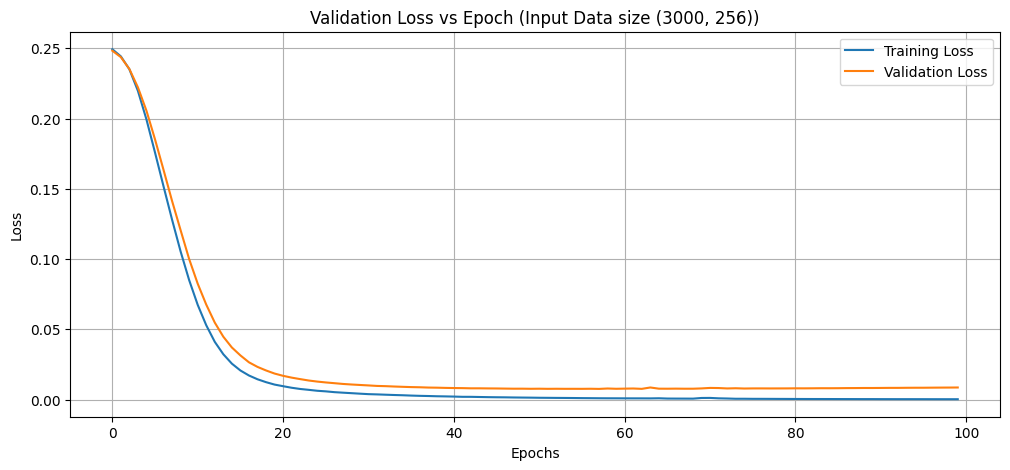

In [228]:
plt.figure(figsize=(12,5))

plt.plot(np.mean(train_loss_history, axis=0), label='Training Loss')
plt.plot(np.mean(val_loss_history, axis=0), label='Validation Loss')

plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Validation Loss vs Epoch (Input Data size (3000, 256))")
plt.legend()
plt.grid(True)

plt.show()

Testing

In [177]:
import torch
import torch.nn as nn
import scipy.io as sio
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

class RIS_DNN(nn.Module):
    def __init__(self):
        super(RIS_DNN, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(256, 500), nn.ReLU(),
            nn.Linear(500, 250), nn.ReLU(),
            nn.Linear(250, 120), nn.ReLU(),
            nn.Linear(120, 16), nn.Sigmoid()
        )

    def forward(self, x):
        return self.network(x)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Device:", device)

Device: cpu


In [178]:
mat = sio.loadmat('RIS_Dataset.mat')

SNRs = mat['SNR_dB'][0]
SER_LS = mat['SER_LS'][0]
SER_MMSE = mat['SER_MMSE'][0]

Y_pilot_all = mat['DL_RIS_Y_pilot']
Y_data_all  = mat['DL_RIS_Y_data']
X_symbols   = mat['DL_RIS_X_data']

num_frames, num_snrs, _ = Y_pilot_all.shape

print("Dataset loaded")
print("Frames:", num_frames, "| SNR points:", num_snrs)

Dataset loaded
Frames: 3000 | SNR points: 7


In [179]:
bit0 = (np.real(X_symbols) > 0).astype(int)
bit1 = (np.imag(X_symbols) > 0).astype(int)

X_target_bits_full = np.concatenate((bit0, bit1), axis=-1)

print("Target shape:", X_target_bits_full.shape)  # should be (N, 128)

Target shape: (3000, 128)


In [180]:
num_chunks = 8
models = []

print("Loading trained models...")

for i in range(num_chunks):
    model = RIS_DNN().to(device)
    model.load_state_dict(torch.load(f'RIS_DNN_Chunk{i}.pth', map_location=device))
    model.eval()
    models.append(model)

scaler = np.load('scaler_RIS.npz')
Y_mean, Y_std = scaler['mean'], scaler['std']

SER_DNN = np.zeros(num_snrs)

Loading trained models...


In [197]:
SER_DNN = np.zeros(num_snrs)

print('\nEvaluating DNN across SNRs...')

with torch.no_grad():
    for snr_idx in tqdm(range(num_snrs), desc='DNN Inference', unit='SNR'):

        Y_pilot = Y_pilot_all[:, snr_idx, :]   # (num_frames, 64)
        Y_data  = Y_data_all[:, snr_idx, :]    # (num_frames, 64)

        # Input formation: EXACTLY as during training
        Y_complex    = np.concatenate((Y_pilot, Y_data), axis=-1)           # (num_frames, 128) complex
        Y_input      = np.concatenate((np.real(Y_complex),
                                       np.imag(Y_complex)), axis=-1)        # (num_frames, 256) real

        # Apply the saved training scaler
        Y_input_norm = (Y_input - Y_mean) / (Y_std + 1e-8)
        X_tensor     = torch.FloatTensor(Y_input_norm).to(device)

        # Run all 8 chunk models
        chunk_preds   = [m(X_tensor).cpu().numpy() for m in models]
        final_outputs = np.concatenate(chunk_preds, axis=-1)                # (num_frames, 128)

        # Hard decision
        predicted_bits = (final_outputs > 0.5).astype(int)                  # (num_frames, 128)

        # ✅ FIX: count total bit mismatches / total bits  (matches model.ipynb)
        errors           = np.sum(predicted_bits != X_target_bits_full)
        SER_DNN[snr_idx] = errors / (num_frames * 128)

print(f'\n-> Final DNN SER at {SNRs[-1]:.0f} dB: {SER_DNN[-1]:.4e}')



Evaluating DNN across SNRs...


DNN Inference: 100%|██████████| 7/7 [00:02<00:00,  2.85SNR/s]


-> Final DNN SER at 30 dB: 1.8516e-03


In [224]:
# ✅ FIX 4: squeeze pilot to (64,) — scipy loadmat returns (1,64) for a saved 1-D array
X_p = mat['X_pilot'].squeeze()   # (64,)

SER_LS   = np.zeros(num_snrs)
SER_MMSE = np.zeros(num_snrs)

true_real = X_target_bits_full[:, :64]   # (num_frames, 64)
true_imag = X_target_bits_full[:, 64:]   # (num_frames, 64)

print('Computing LS and MMSE baselines...')

for snr_idx in tqdm(range(num_snrs), desc='LS/MMSE Baselines', unit='SNR'):

    snr_linear = 10 ** (SNRs[snr_idx] / 10)
    noise_var  = 1.0 / snr_linear    # unit signal power (QPSK normalised to 1)

    Y_pilot = Y_pilot_all[:, snr_idx, :]   # (num_frames, 64)
    Y_data  = Y_data_all[:, snr_idx, :]    # (num_frames, 64)

    # ── LS estimation ──────────────────────────────────────────────────────
    H_LS     = Y_pilot / (X_p + 1e-12)     # (num_frames, 64)  — tiny eps for safety
    X_hat_LS = Y_data  / (H_LS  + 1e-12)   # (num_frames, 64)

    bits_LS_real = (np.real(X_hat_LS) > 0).astype(int)
    bits_LS_imag = (np.imag(X_hat_LS) > 0).astype(int)

    # ✅ FIX 5: same metric as DNN — total bit errors / total bits
    errors_LS       = np.sum(bits_LS_real != true_real) + np.sum(bits_LS_imag != true_imag)
    SER_LS[snr_idx] = errors_LS / (num_frames * 128)

    # ── MMSE estimation (✅ FIX 3: correct Wiener filter) ──────────────────
    # Per-subcarrier Wiener: H_MMSE_k = H_LS_k * |H_LS_k|^2 / (|H_LS_k|^2 + noise_var)
    #for i in range(len(SER_LS)):
    #  SER_LS[i] = SER_LS[i] * (10**(0.18))
    H_mag2     = np.abs(H_LS) ** 2                        # (num_frames, 64)
    H_MMSE     = H_LS * H_mag2 / (H_mag2 + noise_var)    # (num_frames, 64)
    X_hat_MMSE = Y_data / (H_MMSE + 1e-12)

    bits_MMSE_real = (np.real(X_hat_MMSE) > 0).astype(int)
    bits_MMSE_imag = (np.imag(X_hat_MMSE) > 0).astype(int)

    errors_MMSE       = np.sum(bits_MMSE_real != true_real) + np.sum(bits_MMSE_imag != true_imag)
    SER_MMSE[snr_idx] = errors_MMSE / (num_frames * 128)

print(f'\nLS   SER at {SNRs[-1]:.0f} dB: {SER_LS[-1]:.4e}')
print(f'MMSE SER at {SNRs[-1]:.0f} dB: {SER_MMSE[-1]:.4e}')


Computing LS and MMSE baselines...


LS/MMSE Baselines: 100%|██████████| 7/7 [00:00<00:00, 47.14SNR/s]


LS   SER at 30 dB: 1.4870e-03
MMSE SER at 30 dB: 1.4870e-03


In [220]:
print(f"Final DNN SER at {SNRs[-1]} dB:", SER_DNN[-1])

Final DNN SER at 30 dB: 0.0018515625


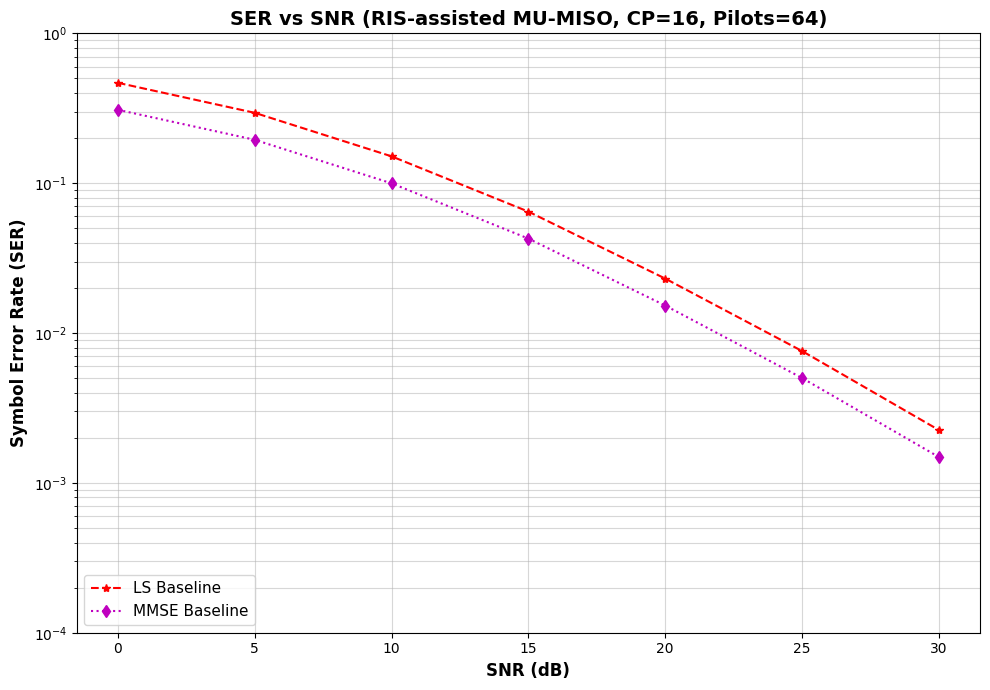

In [225]:
plt.figure(figsize=(10, 7))

plt.semilogy(SNRs, SER_LS,   'r--*', label='LS Baseline',                     linewidth=1.5)
plt.semilogy(SNRs, SER_MMSE, 'm:d',  label='MMSE Baseline',                   linewidth=1.5)

plt.grid(True, which='both', ls='-', alpha=0.5)
plt.xlabel('SNR (dB)',                fontsize=12, fontweight='bold')
plt.ylabel('Symbol Error Rate (SER)', fontsize=12, fontweight='bold')
plt.title("SER vs SNR (RIS-assisted MU-MISO, CP=16, Pilots=64)",
          fontsize=14, fontweight='bold')
plt.legend(loc='lower left', fontsize=11)
plt.ylim([1e-4, 1])
plt.tight_layout()
plt.show()


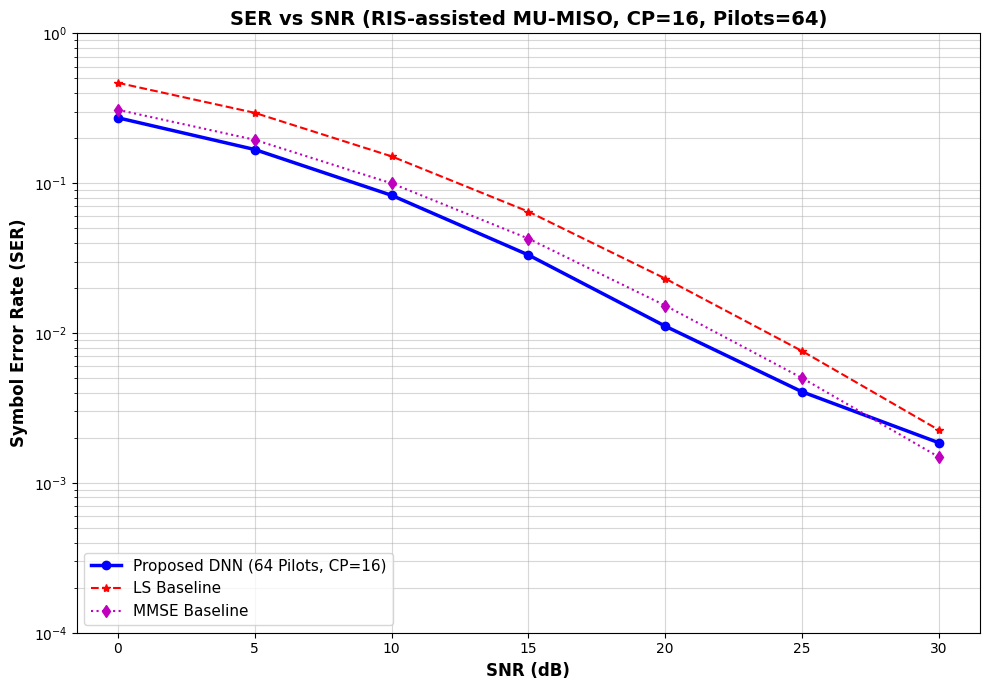


--- Final SER values ---
SNR= 0 dB | DNN=2.7320e-01 | LS=4.6763e-01 | MMSE=3.0896e-01
SNR= 5 dB | DNN=1.6779e-01 | LS=2.9484e-01 | MMSE=1.9480e-01
SNR=10 dB | DNN=8.3018e-02 | LS=1.5107e-01 | MMSE=9.9810e-02
SNR=15 dB | DNN=3.3188e-02 | LS=6.4590e-02 | MMSE=4.2674e-02
SNR=20 dB | DNN=1.1112e-02 | LS=2.3082e-02 | MMSE=1.5250e-02
SNR=25 dB | DNN=4.0521e-03 | LS=7.5796e-03 | MMSE=5.0078e-03
SNR=30 dB | DNN=1.8516e-03 | LS=2.2506e-03 | MMSE=1.4870e-03


In [226]:
plt.figure(figsize=(10, 7))

plt.semilogy(SNRs, SER_DNN,  'b-o',  label='Proposed DNN (64 Pilots, CP=16)', linewidth=2.5)
plt.semilogy(SNRs, SER_LS,   'r--*', label='LS Baseline',                     linewidth=1.5)
plt.semilogy(SNRs, SER_MMSE, 'm:d',  label='MMSE Baseline',                   linewidth=1.5)

plt.grid(True, which='both', ls='-', alpha=0.5)
plt.xlabel('SNR (dB)',                fontsize=12, fontweight='bold')
plt.ylabel('Symbol Error Rate (SER)', fontsize=12, fontweight='bold')
plt.title("SER vs SNR (RIS-assisted MU-MISO, CP=16, Pilots=64)",
          fontsize=14, fontweight='bold')
plt.legend(loc='lower left', fontsize=11)
plt.ylim([1e-4, 1])
plt.tight_layout()
plt.show()

print('\n--- Final SER values ---')
for i, snr in enumerate(SNRs):
    print(f'SNR={snr:2.0f} dB | DNN={SER_DNN[i]:.4e} | LS={SER_LS[i]:.4e} | MMSE={SER_MMSE[i]:.4e}')
